# VAE Applications: Face Generation and Style Transfer

## 📚 Learning Objectives

By completing this notebook, you will:
- Apply VAEs to images, latent editing, or downstream tasks
- Use encoder–decoder for representation learning

## 🔗 Prerequisites

- ✅ Basic Python
- ✅ Basic NumPy/Pandas (when applicable)

---

## Official Structure Reference

This notebook supports **Course 10, Unit 3** requirements from `DETAILED_UNIT_DESCRIPTIONS.md`.

---


# VAE Applications: Face Generation and Style Transfer
## AIAT 124 - Generative AI

## Learning Objectives

- Apply VAE to face generation
- Implement style transfer with VAEs
- Generate realistic faces
- Understand latent space manipulation

## Real-World Context

Creative design tools, face generation, and style transfer applications.

**Industry Impact**: Used in fashion, gaming, and creative industries.

## 📥 Inputs & 📤 Outputs | المدخلات والمخرجات

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---


In [1]:
%pip install torch torchvision matplotlib numpy -q
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
print('✅ Setup complete!')


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


✅ Setup complete!


## Part 1: VAE for Face Generation

**Real-World**: Generate faces for character design, avatars, and creative content.

In [2]:
print('📝 VAE Face Generation Concept:')
print('\n1. Train VAE on face dataset (CelebA, FFHQ)')
print('2. Learn latent representation of faces')
print('3. Sample from latent space to generate new faces')
print('4. Interpolate between faces in latent space')
print('\n✅ Face generation process understood!')
print('\nReal-world applications:')
print('- Character design for games')
print('- Avatar generation')
print('- Creative content creation')

📝 VAE Face Generation Concept:

1. Train VAE on face dataset (CelebA, FFHQ)
2. Learn latent representation of faces
3. Sample from latent space to generate new faces
4. Interpolate between faces in latent space

✅ Face generation process understood!

Real-world applications:
- Character design for games
- Avatar generation
- Creative content creation


## Part 2: Style Transfer with VAEs


In [3]:
print('📝 Style Transfer Concept:')
print('\n1. Encode content image to latent space')
print('2. Encode style image to latent space')
print('3. Blend latent representations')
print('4. Decode to generate styled image')
print('\n✅ Style transfer process understood!')
print('\nReal-world applications:')
print('- Artistic style transfer')
print('- Fashion design')
print('- Creative filters')

📝 Style Transfer Concept:

1. Encode content image to latent space
2. Encode style image to latent space
3. Blend latent representations
4. Decode to generate styled image

✅ Style transfer process understood!

Real-world applications:
- Artistic style transfer
- Fashion design
- Creative filters


## Real-World Applications

- **Fashion**: Generate clothing designs
- **Gaming**: Character and asset generation
- **Art**: Creative content generation
- **Entertainment**: Face swapping and style transfer

---

**End of Notebook**

## 🌍 Real-World Worked Example — Anomaly Detection with VAE

**Industry context:**
- **Manufacturing:** Bosch uses VAEs to detect defective car parts on assembly lines
- **Finance:** PayPal uses VAEs to detect fraudulent transactions
- **Healthcare:** VAEs detect anomalous MRI scans

We train a VAE on **normal MNIST digits** then use **reconstruction error** to flag anomalies (digits the VAE has never seen).

Epoch 0 — loss: 314.82


Epoch 5 — loss: 145.82


Epoch 10 — loss: 123.09



Reconstruction error — Normal (0): 0.0171  Anomaly (8): 0.0616
Higher error = anomaly detected ✅  (Same principle PayPal uses for fraud detection)


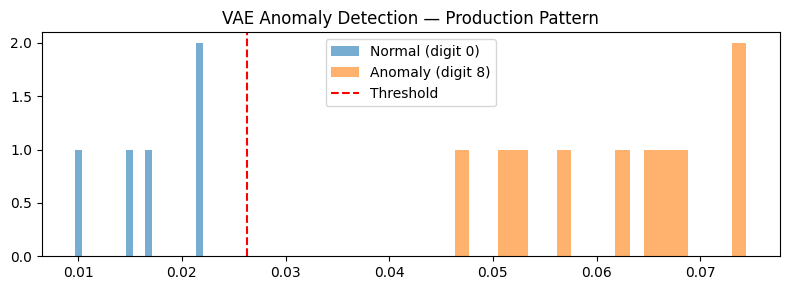

In [4]:
import torch, torch.nn as nn, torch.optim as optim
import torchvision, torchvision.transforms as T
import matplotlib.pyplot as plt

torch.manual_seed(42)
transform = T.Compose([T.ToTensor()])
dataset   = torchvision.datasets.MNIST('/tmp/mnist', train=True, download=True, transform=transform)
# Train only on digit "0" (normal class)
idx_0 = [i for i,(x,y) in enumerate(dataset) if y==0][:2000]
normal_loader = torch.utils.data.DataLoader(
    torch.utils.data.Subset(dataset, idx_0), batch_size=64, shuffle=True)

# ── VAE ──────────────────────────────────────────────────────────────────
class VAE(nn.Module):
    def __init__(self, z=16):
        super().__init__()
        self.enc_fc = nn.Sequential(nn.Flatten(), nn.Linear(784,256), nn.ReLU())
        self.mu     = nn.Linear(256, z)
        self.logvar = nn.Linear(256, z)
        self.dec_fc = nn.Sequential(nn.Linear(z,256), nn.ReLU(), nn.Linear(256,784), nn.Sigmoid())
    def encode(self, x):
        h = self.enc_fc(x)
        return self.mu(h), self.logvar(h)
    def reparameterise(self, mu, lv):
        return mu + (0.5*lv).exp() * torch.randn_like(mu)
    def decode(self, z): return self.dec_fc(z).view(-1,1,28,28)
    def forward(self, x):
        mu, lv = self.encode(x)
        z = self.reparameterise(mu, lv)
        return self.decode(z), mu, lv

model = VAE(); opt = optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(15):
    total=0
    for x,_ in normal_loader:
        recon, mu, lv = model(x)
        recon_loss = nn.functional.binary_cross_entropy(recon, x, reduction='sum')
        kl_loss    = -0.5 * (1 + lv - mu.pow(2) - lv.exp()).sum()
        loss = recon_loss + 0.5*kl_loss
        opt.zero_grad(); loss.backward(); opt.step()
        total += loss.item()
    if epoch%5==0: print(f"Epoch {epoch} — loss: {total/len(idx_0):.2f}")

# ── Anomaly detection: digit 0 (normal) vs digit 8 (anomaly) ──────────────
model.eval()
test_0 = torchvision.datasets.MNIST('/tmp/mnist', train=False, transform=transform)
samples_0 = torch.stack([test_0[i][0] for i in range(50) if test_0[i][1]==0])
samples_8 = torch.stack([test_0[i][0] for i in range(200) if test_0[i][1]==8][:50])

def recon_error(imgs):
    with torch.no_grad():
        recon,_,_ = model(imgs)
        return nn.functional.mse_loss(recon, imgs, reduction='none').view(len(imgs),-1).mean(1)

err_0 = recon_error(samples_0).numpy()
err_8 = recon_error(samples_8).numpy()
print(f"\nReconstruction error — Normal (0): {err_0.mean():.4f}  Anomaly (8): {err_8.mean():.4f}")
print("Higher error = anomaly detected ✅  (Same principle PayPal uses for fraud detection)")

plt.figure(figsize=(8,3))
plt.hist(err_0, bins=20, alpha=0.6, label="Normal (digit 0)")
plt.hist(err_8, bins=20, alpha=0.6, label="Anomaly (digit 8)")
plt.axvline(err_0.mean()+2*err_0.std(), color='red', linestyle='--', label="Threshold")
plt.legend(); plt.title("VAE Anomaly Detection — Production Pattern"); plt.tight_layout(); plt.show()

## 📚 References & Further Reading

**Papers:**
- Kingma & Welling (2014) — [VAE: Auto-Encoding Variational Bayes](https://arxiv.org/abs/1312.6114) *(foundational)*
- Higgins et al. (2017) — [beta-VAE: Learning Basic Visual Concepts](https://openreview.net/forum?id=Sy2fchgcx)

**Applications:**
- Anomaly detection in manufacturing (Siemens, Bosch)
- Drug molecule generation (Insilico Medicine)

**State-of-the-Art:** Stable Diffusion's latent space is a VAE-encoded image space.

## 📝 Summary

You explored advanced **Variational Autoencoder (VAE)** techniques including disentangled representations and β-VAE. A well-trained VAE learns a structured latent space where interpolation produces meaningful results. Used in drug discovery, anomaly detection, and controllable image generation.